# 5. Operaciones lógicas

## Librerias

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

## Carga y visualizacion

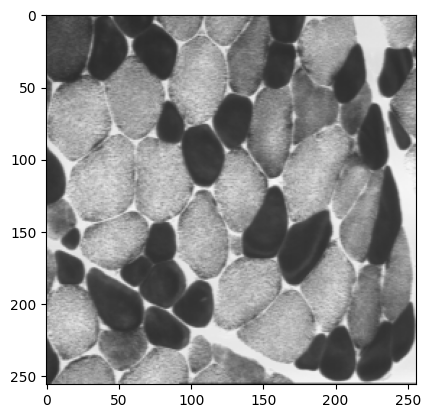

In [2]:
muscle_img = cv2.imread('../img/MUSCLE.png')

plt.imshow(muscle_img)
plt.show()

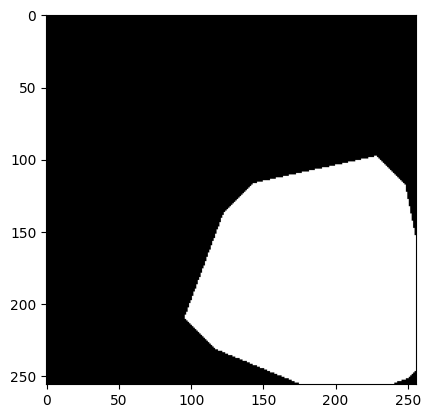

In [3]:
spot_img = cv2.imread('../img/SPOT.png')

plt.imshow(spot_img)
plt.show()

## Operaciones lógicas (muscle, spot)

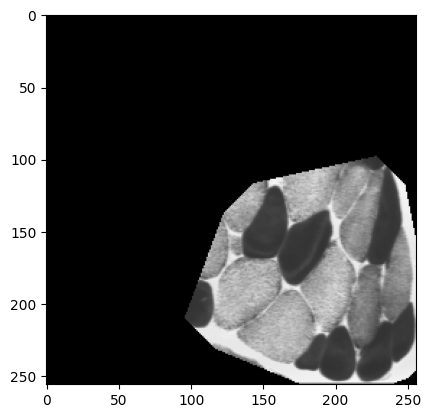

In [4]:
and_img = cv2.bitwise_and(muscle_img, spot_img)

plt.imshow(and_img)
plt.show()

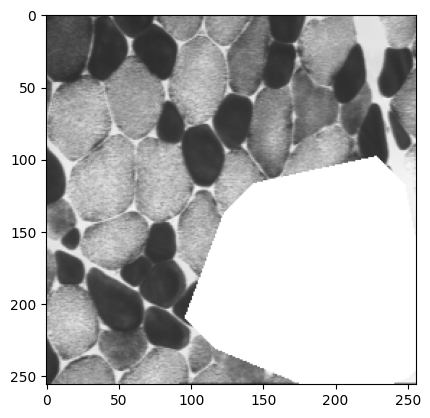

In [5]:
or_img = cv2.bitwise_or(muscle_img, spot_img)

plt.imshow(or_img)
plt.show()

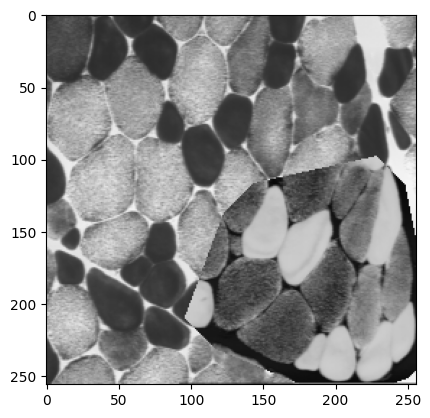

In [6]:
xor_img = cv2.bitwise_xor(muscle_img, spot_img)

plt.imshow(xor_img)
plt.show()

### Conclusion

De las imagenes anteriores se puede observar que la operacion AND entre las imagenes muscle y spot, actua como filtro donde los valores en blanco de spot permiten el paso de los valores de muscle mientras que, los valores oscuros eliminan cualquier valor y oscurecen la imagen. Por otro lado, la operacion OR aplica un 'parche' o zona blanca sobre muscle en la misma region cuyos valores de spot son blancos y dejan pasar cualquier valor en muscle si los valores en spot son negros. Finalmente, la operacion XOR, actual como filtro invertido dentro de la zona blanca en spot. Esto quiere decir que, invierte los valores de muscle, convirtiendo los tonos claros en oscuros y viceversa.

## Operaciones lógicas (spot, muscle)

In [7]:
def plot_imgs_side_by_side(img1, img2, title1='muscle, spot', title2='spot, muscle'):
  """ funcion para mostrar dos imagenes en la misma figura """
  fig, axes = plt.subplots(1, 2, figsize=(8, 4))

  axes[0].imshow(img1)
  axes[0].set_title(title1)
  axes[0].axis("off")

  axes[1].imshow(img2)
  axes[1].set_title(title2)
  axes[1].axis("off")

  plt.tight_layout()
  plt.show()

### Comparativa

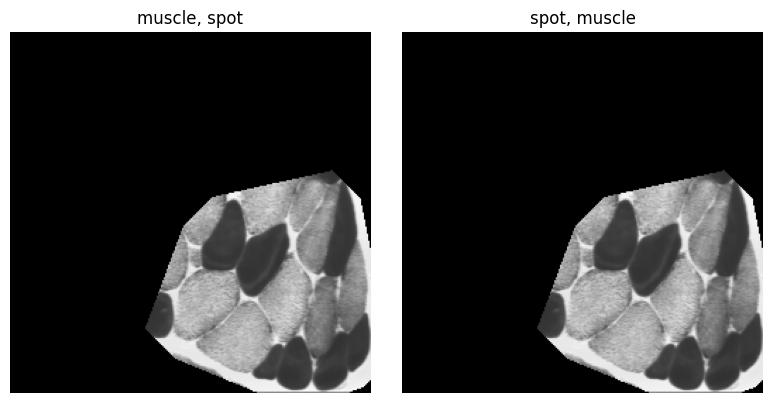

In [8]:
and_img_inv = cv2.bitwise_and(spot_img, muscle_img)

plot_imgs_side_by_side(and_img, and_img_inv)

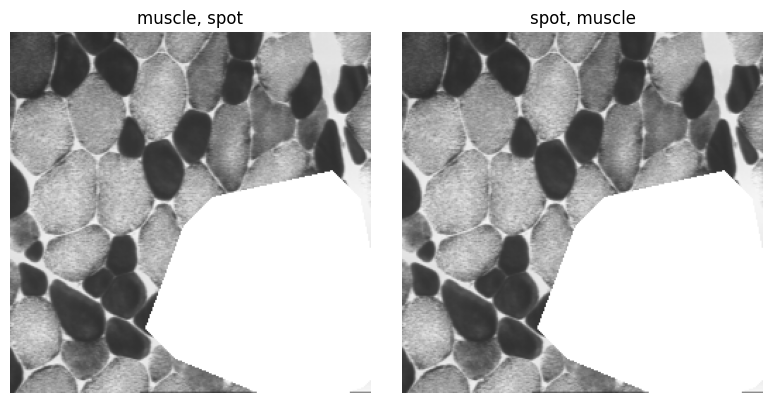

In [9]:
or_img_inv = cv2.bitwise_or(spot_img, muscle_img)

plot_imgs_side_by_side(or_img,or_img_inv)

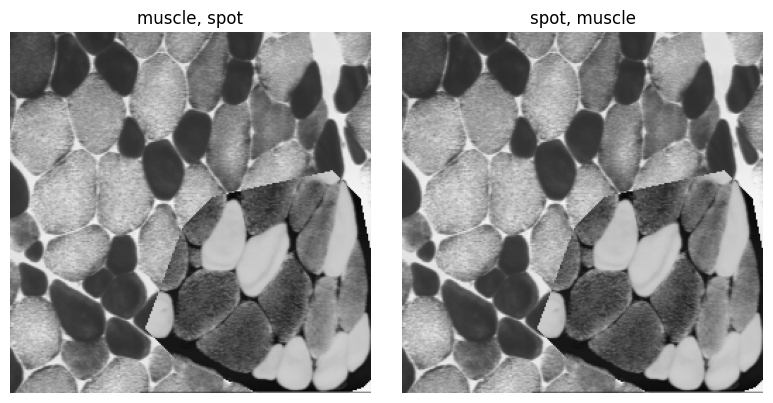

In [10]:
xor_img_inv = cv2.bitwise_xor(spot_img, muscle_img)

plot_imgs_side_by_side(xor_img, xor_img_inv)

### Conclusión

De la comparativa entre las operaciones lógicas aplicadas en el order de muscle y spot y nuevamente sobre spot y muscle, se puede ver que los resultados de las operaciones son iguales en ambos casos. Esto se debe a que las operaciones AND, OR y XOR son conmutativas, el orden de sus operandos no afecta el resultado de la operación. Como validación adicional en la siguiente celda se evalua si todos los valores entre las imagenes resultado de cada operación son iguales entre si.

In [11]:
assert np.all(and_img == and_img_inv)
assert np.all(or_img == or_img_inv)
assert np.all(xor_img == xor_img_inv)

## Operación NOT

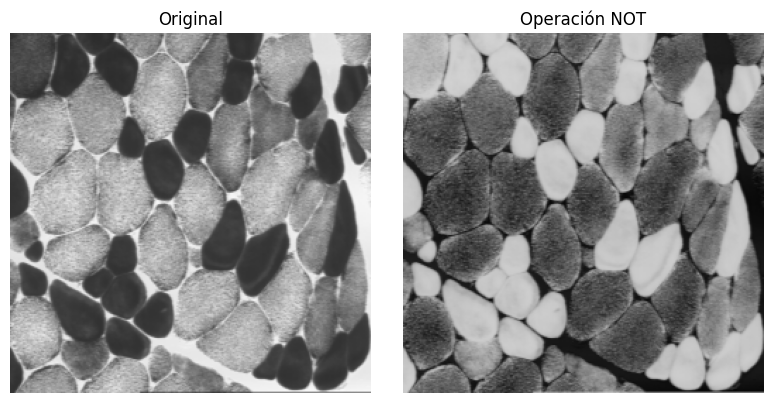

In [12]:
# imagen blanca
blank_img = np.full(muscle_img.shape,255,dtype=np.uint8)

# Operacion NOT usando XOR
not_muscle_img = cv2.bitwise_xor(blank_img, muscle_img)

plot_imgs_side_by_side(muscle_img, not_muscle_img,title1='Original',title2='Operación NOT')

### Conclusión

La operación NOT invierte los colores de la imagen muscle, convirtiendo los colores claros en oscuros y viceversa. Al contrario que la operación XOR anterior donde se invierte algunos valores, la operación NOT se aplica a todos los valores de la imagen.

## Apagar los seis bits menos significativos

Para poner en cero los seis bits menos significativos se crea una máscara a partir de la imagen spot. Primero se aplica la operación NOT para invertir sus valores, los colores blancos se convierten en negros y viceversa. Esto se hace para llevar a cero los píxeles dentro de la zona interés. La razón de esto es porque se quiere desactivar todos los bits de esta zona para posteriormente encender unicamente los bits mas significativos mediante la operación OR. Para esto se crea una imagen con valores de 192 es decir $(11000000)_2$


Por lo tanto, la mascara para este punto se calcula a partir de la siguiente formula

$mascara = OR( NOT(spot), 192 )$

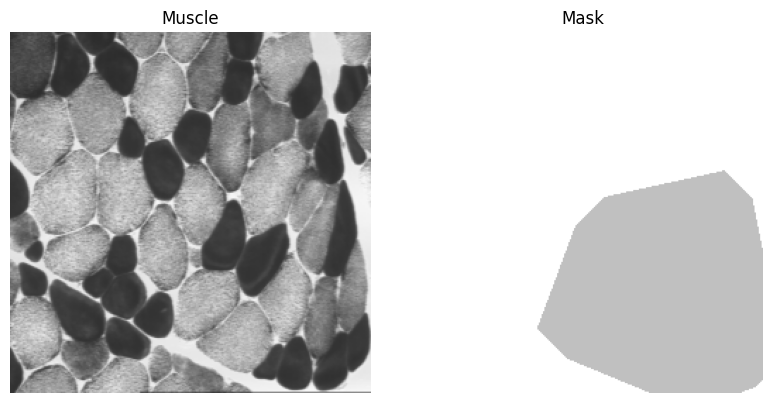

In [13]:
mask = cv2.bitwise_not(spot_img)
mask = cv2.bitwise_or( mask, np.full(spot_img.shape,192,dtype=np.uint8) )

plot_imgs_side_by_side(muscle_img, mask, title1='Muscle',title2='Mask')

Finalmente se aplica la mascara obtenida sobre muscle

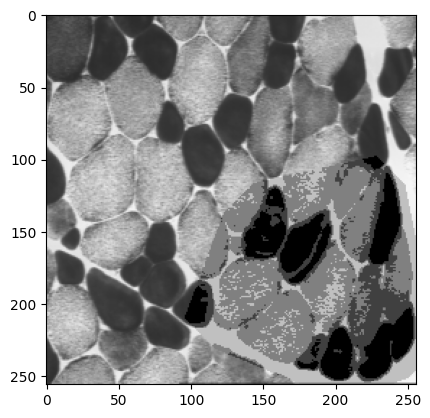

In [14]:
masked_muscle_img = cv2.bitwise_and(muscle_img, mask)

plt.imshow(masked_muscle_img)
plt.show()

Para comprobar los valores que tiene la zona de interes, se aplica una mascara obtenida de invertir los valores de spot para aislar la zona y poder obtener sus valores con la función $np.unique$

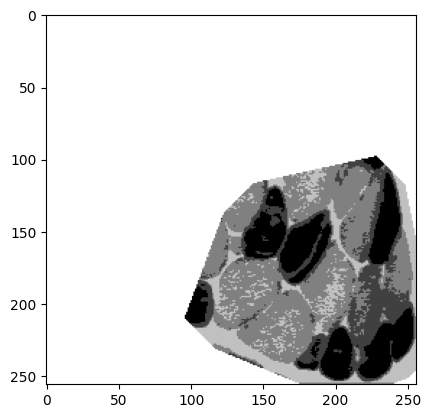

Los valores unicos de esta imagen son: [  0  64 128 192 255]


In [15]:
# invertimos spot
not_spot_img = cv2.bitwise_xor(spot_img, blank_img)

# aislamos la zona de interes
or_img = cv2.bitwise_or(masked_muscle_img, not_spot_img )

# visualizamos el resultado
plt.imshow(or_img)
plt.show()


# obtenemos los valores unicos
print(f'Los valores unicos de esta imagen son: {np.unique(or_img)}')

Como se puede observar en la imagen anterior, los valores únicos en la zona de interes son 0, 64, 128 y 192. Adicional a estos valores está el valor 255 por la zona exterior de la zona de interés